# data reading

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [3]:
df=pd.read_csv("Visadataset.csv")

In [4]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [5]:
# figuring the number of null values null values
df.isna().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [6]:
# looking for duplicate Values
df.duplicated().sum()               

np.int64(0)

In [7]:
# loading the complete information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [8]:

# analysis :
# [ continent,	education_of_employee,has_job_experience,requires_job_training,	region_of_employment	prevailing_wage	unit_of_wage	full_time_position] ---> object type
#  [no_of_employees	yr_of_estab] ---> int type
#  [prevailing_wage]	---? float type


In [9]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [10]:
# as minimum number of employes are negative that is not possible so what we do is to replace the value by minimum value in the dataset    
df["no_of_employees"] = df["no_of_employees"].apply(lambda x: np.nan if x <= 0 else x)
min_positive = df["no_of_employees"][df["no_of_employees"] > 0].min()
df["no_of_employees"] = df["no_of_employees"].fillna(min_positive)


df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.081750,1979.409929,74455.814592
std,22877.919295,42.366929,52815.942327
min,12.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


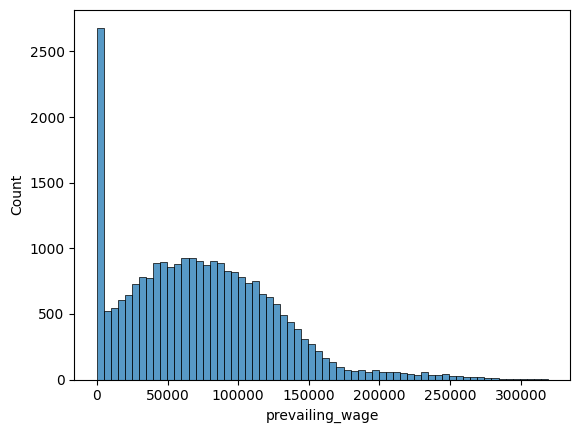

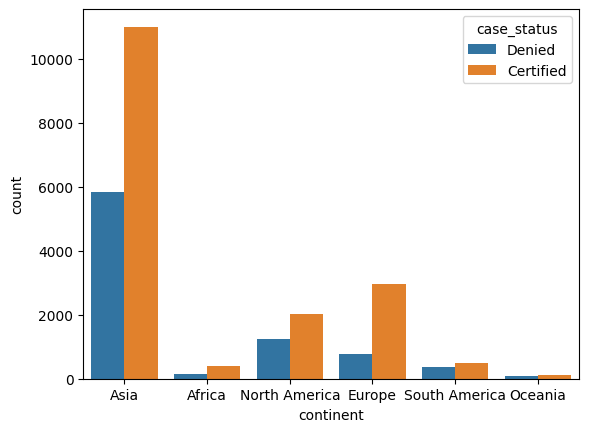

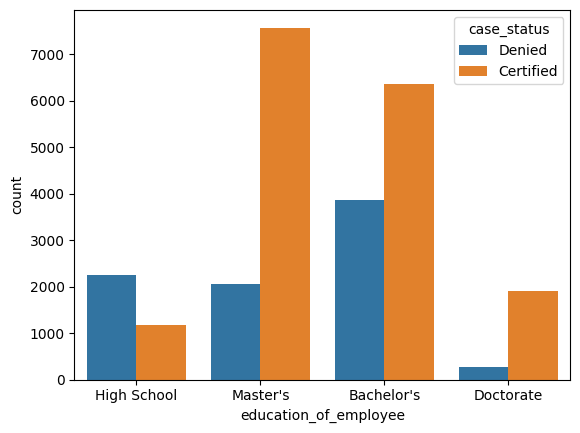

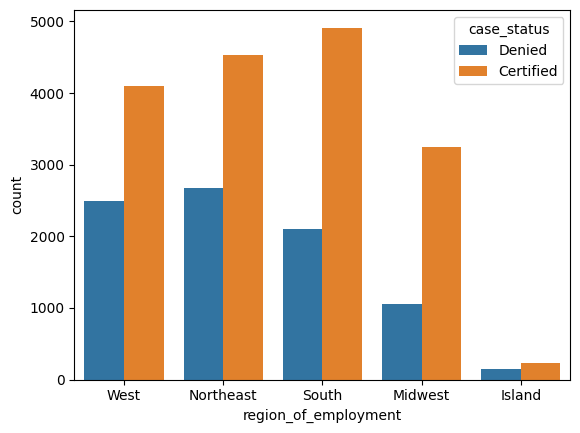

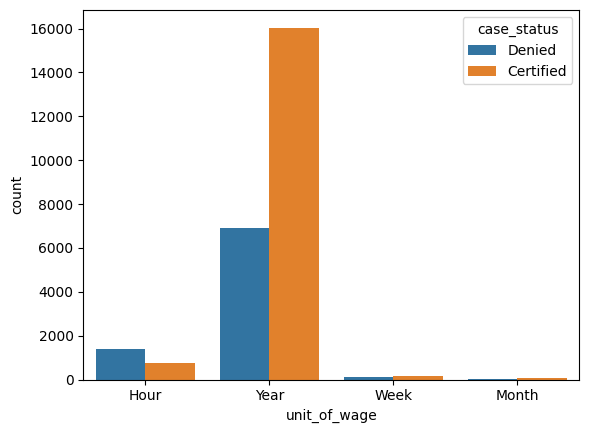

In [11]:
sns.histplot(x=df["prevailing_wage"])
plt.show()
sns.countplot(x="continent",hue=df["case_status"],data=df)
plt.show()
sns.countplot(x="education_of_employee",hue=df["case_status"],data=df)
plt.show()
sns.countplot(x="region_of_employment",hue=df["case_status"],data=df)
plt.show()
sns.countplot(x="unit_of_wage",hue=df["case_status"],data=df)
plt.show()

In [12]:

# 1. from understanding graphs i m thinking to club  continet [oceania , Africa and South America ] into a fetaure naming other because all they have is very little number of points and have almost equal splits betwen case_status 

# 2. i will club the [prevailing_wage,unit_of_wage] into a single a single filed under the name wage considering 40 hr/week and 52 week/year



In [13]:
# importing function to convert the fields from a file name functions.py because these same functions will be used when i convert the user inputs

from functions import calc_company_age,calc_wage,convert_continent,label_company_size
from datetime import datetime

In [14]:
df["yearly_wage"]=df.apply(calc_wage,axis=1).astype(int)
df["company_size"]=df.apply(label_company_size,axis=1).astype(int)
df["continents_modified"]=df.apply(convert_continent,axis=1).astype(int)
df["company_age"]=df.apply(calc_company_age,axis=1).astype(int)


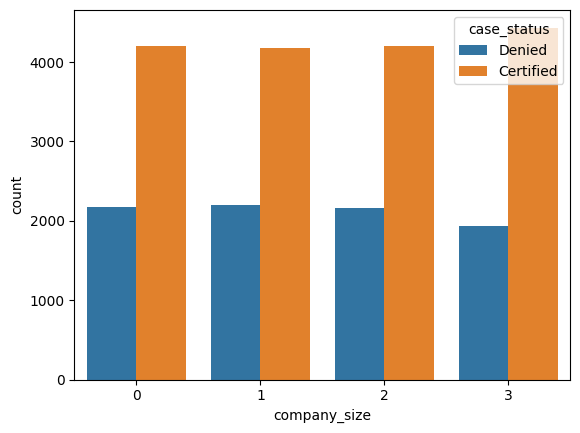

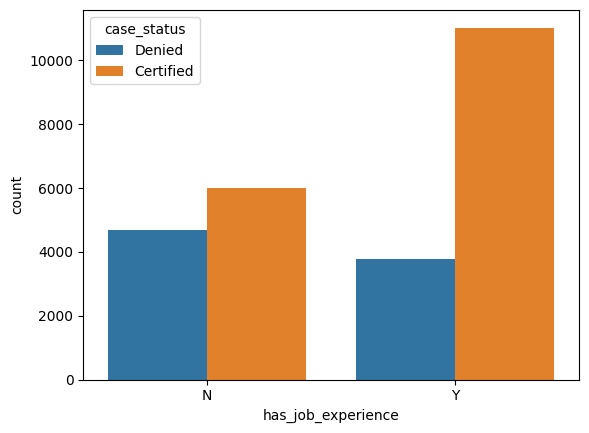

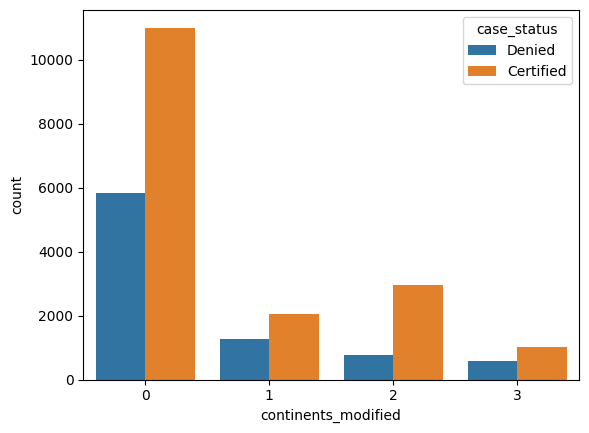

In [15]:
# viewing data with respect to new features and output 
sns.countplot(x="company_size",hue=df["case_status"],data=df)
plt.show()
sns.countplot(x="has_job_experience",hue=df["case_status"],data=df)
plt.show()
sns.countplot(x="continents_modified",hue=df["case_status"],data=df)
plt.show()

In [16]:
# viewing the total colums present in the dataset
df.columns

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status', 'yearly_wage', 'company_size',
       'continents_modified', 'company_age'],
      dtype='object')

In [17]:
# dropping case_id because even though it is unique but has noting to do with the visa being Denied or Certified
# removing "continent" because i have "continent_modified"
#removing "requires_job_training" because it is irrelevant from your visa grant
#removing "no_of_employees" because i have converted it into a categorical feature of "company_size"
#removing "yr_of_estab" because i have converted it into a continuous feature of "company_age"
#removing "" because i have converted it into a continuous feature of "company_age"
# 'prevailing_wage', 'unit_of_wage' becuase i have converted it into a continuous feature called "yearly_wage"
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,yearly_wage,company_size,continents_modified,company_age
0,EZYV01,Asia,High School,N,N,14513.0,2007,West,592.2029,Hour,Y,Denied,1231782,3,0,18
1,EZYV02,Asia,Master's,Y,N,2412.0,2002,Northeast,83425.6500,Year,Y,Certified,83425,2,0,23
2,EZYV03,Asia,Bachelor's,N,Y,44444.0,2008,West,122996.8600,Year,Y,Denied,122996,3,0,17
3,EZYV04,Asia,Bachelor's,N,N,98.0,1897,West,83434.0300,Year,Y,Denied,83434,0,0,128
4,EZYV05,Africa,Master's,Y,N,1082.0,2005,South,149907.3900,Year,Y,Certified,149907,1,3,20


In [18]:
# selecting only useful features from the data set
df=df[["continents_modified","education_of_employee","has_job_experience","region_of_employment","full_time_position","yearly_wage","company_size","company_age","case_status"]]

In [19]:
df["has_job_experience"]=df["has_job_experience"].apply(lambda x:1 if x=="Y" else 0)
df["full_time_position"]=df["full_time_position"].apply(lambda x:1 if x=="Y" else 0)

In [20]:
df.dtypes

continents_modified       int64
education_of_employee    object
has_job_experience        int64
region_of_employment     object
full_time_position        int64
yearly_wage               int64
company_size              int64
company_age               int64
case_status              object
dtype: object

In [21]:
# creating dependent and independent features alonf with mapping of "Denied"  to 0 and "Certified" to 1  
X=df.drop("case_status",axis=1)
Y=df["case_status"].map({"Denied":0,"Certified":1})
Y.dtype

dtype('int64')

In [22]:
import pickle
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Separate encoders
edu_encoder = LabelEncoder()
region_encoder = LabelEncoder()
wage_scaler = StandardScaler()

# Encode categorical columns
edu_encoder.fit(["High School","Bachelor's","Master's","Doctorate"])
pickle.dump(edu_encoder, open("education_encoder.pkl", "wb"))

X["education_of_employee"] = edu_encoder.transform(X["education_of_employee"])

region_encoder.fit(["West","Northeast","South","Midwest","Island"])
pickle.dump(region_encoder, open("region_encoder.pkl", "wb"))

X["region_of_employment"] = region_encoder.transform(X["region_of_employment"])



In [23]:
X["full_time_position"].value_counts()

full_time_position
1    22773
0     2707
Name: count, dtype: int64

In [24]:
X
# performing train test split
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
xtrain,xtest,ytrain,ytest=train_test_split(X,Y,test_size=0.20,random_state=42)


In [25]:
xtrain[["yearly_wage"]] = wage_scaler.fit_transform(xtrain[["yearly_wage"]])
pickle.dump(wage_scaler, open("yearly_wage_scaler.pkl", "wb"))
xtest[["yearly_wage"]] = wage_scaler.transform(xtest[["yearly_wage"]])

company_age_scaler=StandardScaler()
xtrain[["yearly_wage"]] = company_age_scaler.fit_transform(xtrain[["company_age"]])
pickle.dump(company_age_scaler, open("company_age_scaler.pkl", "wb"))
xtest[["yearly_wage"]] = company_age_scaler.transform(xtest[["company_age"]])



In [42]:
smote=SMOTE(random_state=42)
xtrain_balanced,ytrain_balanced=smote.fit_resample(xtrain,ytrain)
ytrain_balanced.value_counts()




xtrain_balanced





,continents_modified,education_of_employee,has_job_experience,region_of_employment,full_time_position,yearly_wage,company_size,company_age
0,0,2,1,4,1,-0.697340,1,16
1,1,3,1,4,1,-0.768227,0,13
2,0,2,1,3,1,-0.602825,0,20
3,0,3,0,4,1,0.413213,0,63
4,2,2,0,4,1,-0.319280,3,32
...,...,...,...,...,...,...,...,...
27229,0,0,0,4,1,-0.579196,3,21
27230,0,3,0,3,1,0.224183,1,55
27231,2,2,0,4,1,-0.484681,1,25
27232,0,2,0,1,1,1.085639,2,91


In [27]:

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.metrics import classification_report,confusion_matrix
from functions import evaluate_model

In [28]:
model_test_results=[]
model_train_results=[]
models={
    "Logistic Regression":LogisticRegression(),
    "Decision Tree Classifier":DecisionTreeClassifier(max_depth=None),
    "SVC":SVC(class_weight="balanced"),
    "Random Forest Classifier":RandomForestClassifier(max_depth=None),
    "Gradient Boosting Classifier":GradientBoostingClassifier(),
    "XGBClassifier":XGBClassifier()
}
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(xtrain_balanced,ytrain_balanced)
    
    # make prdiction 
    y_train_pred=model.predict(xtrain_balanced)
    y_test_pred=model.predict(xtest)
    
    # trainig performance
    train_model_accuracy,train_model_f1,train_model_precision,train_model_recall,train_model_roc_auc,train_model_confusion_matrix=evaluate_model(ytrue=ytrain_balanced,ypred=y_train_pred)
    
    # test performance
    test_model_accuracy,test_model_f1,test_model_precision,test_model_recall,test_model_roc_auc,test_model_confusion_matrix=evaluate_model(ytrue=ytest,ypred=y_test_pred)
    
    model_test_results.append({
            "model_name":list(models.keys())[i],
            "Accuracy": round(test_model_accuracy, 4),
            "F1-Score": round(test_model_f1, 4),
            "Precision": round(test_model_precision, 4),
            "Recall": round(test_model_recall, 4),
            "ROC AUC": round(test_model_roc_auc, 4),
            "confusion_matrix":test_model_confusion_matrix
        }
    )
    model_train_results.append({
            "model_name":list(models.keys())[i],
            "Accuracy": round(train_model_accuracy, 4),
            "F1-Score": round(train_model_f1, 4),
            "Precision": round(train_model_precision, 4),
            "Recall": round(train_model_recall, 4),
            "ROC AUC": round(train_model_roc_auc, 4),
            "confusion_matrix":train_model_confusion_matrix
        }
    )
    

In [29]:
model_test_results_df=pd.DataFrame(model_test_results)
model_train_results_df=pd.DataFrame(model_train_results)

In [30]:
print("displaying training data results")
model_train_results_df

displaying training data results


,model_name,Accuracy,F1-Score,Precision,Recall,ROC AUC,confusion_matrix
0,Logistic Regression,0.6335,0.6381,0.6302,0.6462,0.6335,0.633510
1,Decision Tree Classifier,0.8928,0.8869,0.9384,0.8408,0.8928,0.892818
2,SVC,0.6189,0.6173,0.6199,0.6147,0.6189,0.618859
3,Random Forest Classifier,0.8927,0.8900,0.9130,0.8681,0.8927,0.892708
4,Gradient Boosting Classifier,0.7142,0.7130,0.7161,0.7098,0.7142,0.714218
5,XGBClassifier,0.7752,0.7719,0.7833,0.7609,0.7752,0.775207


In [31]:
print("displaying test data results")

model_test_results_df

displaying test data results


,model_name,Accuracy,F1-Score,Precision,Recall,ROC AUC,confusion_matrix
0,Logistic Regression,0.6162,0.6917,0.7455,0.6451,0.6016,0.601608
1,Decision Tree Classifier,0.6391,0.7132,0.7593,0.6724,0.6224,0.622360
2,SVC,0.6038,0.6765,0.7433,0.6207,0.5953,0.595306
3,Random Forest Classifier,0.6625,0.7390,0.7636,0.7160,0.6356,0.635564
4,Gradient Boosting Classifier,0.7029,0.7624,0.8176,0.7142,0.6972,0.697219
5,XGBClassifier,0.7013,0.7642,0.8077,0.7251,0.6894,0.689384


In [35]:
from sklearn.model_selection import GridSearchCV
xgb_model=XGBClassifier()
xgb_params = {
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5, 7],
}

In [36]:
grid_model=GridSearchCV(xgb_model,xgb_params,cv=5,verbose=3,refit=True)

In [37]:
grid_model.fit(xtrain_balanced,ytrain_balanced)

Fitting 5 folds for each of 256 candidates, totalling 1280 fits
[CV 1/5] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100;, score=0.682 total time=   0.1s
[CV 2/5] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100;, score=0.676 total time=   0.0s
[CV 3/5] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100;, score=0.702 total time=   0.0s
[CV 4/5] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100;, score=0.719 total time=   0.0s
[CV 5/5] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100;, score=0.728 total time=   0.1s
[CV 1/5] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=200;, score=0.683 total time=   0.1s
[CV 2/5] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=200;, score=0.679 total time=   0.1s
[CV 3/5] END learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=200;, score=0.704 total time=   0.1s
[CV 4/5]

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.2, 0.3],
                         'max_depth': [3, 5, 7, 9],
                         'min_child_weight': [1, 3, 5, 7],
                         'n_estimators': [100, 200, 300, 500]},
             verbose=3)

In [38]:
grid_model.best_params_

{'learning_rate': 0.1,
 'max_depth': 9,
 'min_child_weight': 1,
 'n_estimators': 500}

In [39]:
xgb_model=XGBClassifier(learning_rate=0.1,max_depth=9,min_child_weight=1,n_estimators=500)
xgb_model.fit(xtrain_balanced,ytrain_balanced)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [40]:
import pickle 
pickle.dump(xgb_model,open("model.pkl","wb"))